In [1]:
# 必要なモジュールをインポート
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# 環境変数の読み込み
load_dotenv("../.env")
os.environ['OPENAI_API_KEY'] = os.environ['API_KEY']

# モデル名
MODEL_NAME = "gpt-4o-mini"

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

# ステートの定義
class State(TypedDict):
    # データを保存する属性
    messages: Annotated[list, add_messages]

# ステートグラフの作成
graph_builder = StateGraph(State)

In [3]:
# 言語モデルの定義
llm = ChatOpenAI(model_name=MODEL_NAME)

# チャットボットノードの作成
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# グラフにチャットボットノードを追加
graph_builder.add_node("chatbot", chatbot)

# 開始ノードの指定
graph_builder.set_entry_point("chatbot")
# 終了ノードの指定
graph_builder.set_finish_point("chatbot")

# 実行可能なステートグラフの作成
graph = graph_builder.compile()

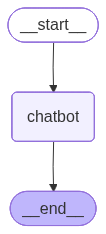

In [5]:
# グラフの可視化
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png())) #Required: Add white domain mermaid.ink 

In [7]:
# グラフの実行
response = graph.invoke({"messages": [("user", "光の三原色は？")]})

# 結果の表示
response

{'messages': [HumanMessage(content='光の三原色は？', additional_kwargs={}, response_metadata={}, id='588380ae-9078-4e09-91fd-cf21ef8a60a7'),
  AIMessage(content='光の三原色は、赤（Red）、緑（Green）、青（Blue）の3色です。これらの色を組み合わせることで、さまざまな色を作り出すことができます。この原理は、テレビやコンピュータのディスプレイなど、光を使った色の表示に利用されています。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 14, 'total_tokens': 92, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_48f18beaba', 'finish_reason': 'stop', 'logprobs': None}, id='run-c6115718-8c4f-4694-8292-cc14e7722cc3-0', usage_metadata={'input_tokens': 14, 'output_tokens': 78, 'total_tokens': 92, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [8]:
# 言語モデルからの回答のみを表示
print(response["messages"][-1].content)


光の三原色は、赤（Red）、緑（Green）、青（Blue）の3色です。これらの色を組み合わせることで、さまざまな色を作り出すことができます。この原理は、テレビやコンピュータのディスプレイなど、光を使った色の表示に利用されています。


In [10]:
# グラフの実行と結果の表示
def stream_graph_updates(user_input: str):
    # 結果をストリーミングで得る
    events = graph.stream({"messages": [("user", user_input)]})
    for event in events:
        for value in event.values():
            print("回答:", value["messages"][-1].content, flush=True)

# チャットボットのループ
while True:
    user_input = input("質問:")
    if user_input.strip()=="":
        print("ありがとうございました!")
        break
    print("質問:", user_input, flush=True)
    stream_graph_updates(user_input)

質問: HSV vs RGB which is perform better implement rainbow effect?
回答: When implementing a rainbow effect, the choice between HSV (Hue, Saturation, Value) and RGB (Red, Green, Blue) color spaces can significantly impact performance and ease of implementation. Here's a comparison of the two:

### HSV Color Space
- **Hue Representation**: The most critical aspect for a rainbow effect is the hue value, which directly corresponds to color. By varying the hue, you can easily create a spectrum of colors, making it straightforward to implement a rainbow effect.
- **Simplicity**: Generating a rainbow effect in HSV is often simpler, as you can loop through hue values (0 to 360 degrees) and keep saturation and value constant or adjust them for desired brightness and intensity.
- **Ease of Adjustment**: Adjusting saturation and brightness independently is easier in HSV, allowing for more control over the appearance of the rainbow effect.

### RGB Color Space
- **Color Mixing**: In RGB, you need to 

In [11]:
from langgraph.checkpoint.memory import MemorySaver

# チェックポインタの作成
memory = MemorySaver()

# 記憶を持つ実行可能なステートグラフの作成
memory_graph = graph_builder.compile(checkpointer=memory)

In [12]:
# グラフの実行と結果の表示
def stream_graph_updates(user_input: str):
    events = memory_graph.stream(
        {"messages": [("user", user_input)]},
        {"configurable": {"thread_id": "1"}},
        stream_mode="values")
    # 結果をストリーミングで得る
    for event in events:
        print(event["messages"][-1].content, flush=True)

# チャットボットのループ
while True:
    user_input = input("質問:")
    if user_input.strip()=="":
        print("ありがとうございました!")
        break
    stream_graph_updates(user_input)

HSV vs RGB
HSV (Hue, Saturation, Value) and RGB (Red, Green, Blue) are two different color models used in various applications, such as computer graphics, image processing, and design. Here's a comparison of the two:

### RGB (Red, Green, Blue)
- **Components**: RGB is an additive color model that combines red, green, and blue light to create a broad spectrum of colors. Each component can have a value typically ranging from 0 to 255 in digital applications, where 0 means the absence of that color and 255 means full intensity.
- **Usage**: Commonly used in displays (monitors, TVs) and digital imaging.
- **Color Creation**: Colors are created by varying the intensity of each of the three colors. For example, (255, 0, 0) represents pure red, (0, 255, 0) represents pure green, and (0, 0, 255) represents pure blue.
- **Limitations**: While RGB is intuitive for devices that emit light, it can be less intuitive for tasks like color selection or manipulation since it does not represent colors 